<a href="https://colab.research.google.com/github/poojya100/6thSem-ML-Lab/blob/main/Lab_6_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1. Iris Dataset

In [1]:
# IMPORT LIBRARIES
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# LOAD DATASET
df = pd.read_csv("iris (1).csv")

# FEATURES & TARGET
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column (target)

# TRAIN-TEST SPLIT (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# LINEAR KERNEL
# -------------------------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("=== Linear Kernel ===")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


# -------------------------------
# RBF KERNEL
# -------------------------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\n=== RBF Kernel ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

=== Linear Kernel ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

=== RBF Kernel ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


2. Letter Recoginition Dataset

Accuracy: 0.36825
Confusion Matrix:
 [[149   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [149   0   0   4   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 68   0  69   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 88   0   0  68   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [124   0  17   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [106   0   0   1   0  31   0   0   0   0   0   0   0   0   0   1   0   0
    0   1   0   0   0   0   0   0]
 [157   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [140   0   0   2   0   0   0   0   0   0   0   0   0   0   0   1   0   0
    0   0   1   0   0   0   0   0]
 [ 48   0   0   0   0   0   0   0  95   0   0   0   0   0   0   1   0   0
    0   0   0   0

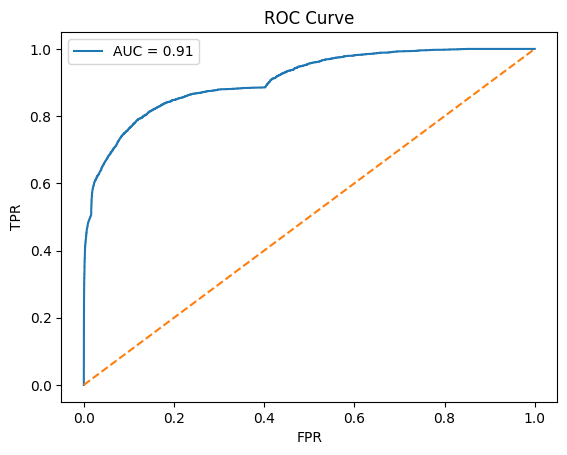

AUC Score: 0.90867287875


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier

# LOAD DATA
df = pd.read_csv("letter-recognition.csv")

# FEATURES & LABEL
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# ENCODE LABELS
y = LabelEncoder().fit_transform(y)

# BINARIZE (for ROC)
y_bin = label_binarize(y, classes=np.unique(y))

# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# TRAIN MODEL
model = OneVsRestClassifier(SVC(kernel='linear'))
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)

# CONVERT BACK TO SINGLE LABEL
y_test_single = np.argmax(y_test, axis=1)
y_pred_single = np.argmax(y_pred, axis=1)

# RESULTS
print("Accuracy:", accuracy_score(y_test_single, y_pred_single))
print("Confusion Matrix:\n", confusion_matrix(y_test_single, y_pred_single))

# ROC + AUC
y_score = model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

# PLOT
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)